# Setup

## Imports

In [1]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Add the project root (the first parent folder containing src/) to sys.path
root_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loading import load_csv_data, load_dataset_config, parse_preprocessing_config
from src.preprocessing import normalize_by_library_size, log_transform, normalize_with_pearson
from src.preprocessing.pipeline import run_filtering_pipeline
from src.visualization import (
    plot_qc_overview,
    plot_gene_set_qc,
    plot_gene_max_count_distribution,
    plot_normalization_comparison,
    plot_log_transform_comparison,
)

## Data Loading

In [4]:
DATA_PATH = root_path / 'data/GSE57249/raw/mouse.embryo.GSE57249.count_matrix.csv.gz'
# The raw file is stored genes x cells
raw_data = load_csv_data(DATA_PATH).T

raw_data

,4933401J01Rik,Gm26206,Xkr4,Gm18956,Gm37180,Gm37363,Gm37686,Gm1992,Gm37329,Gm7341,...,mt-Nd4,mt-Th,mt-Ts2,mt-Tl2,mt-Nd5,mt-Nd6,mt-Te,mt-Cytb,mt-Tt,mt-Tp
GSM1377886,0,0,0,0,0,0,0,0,0,0,...,0,3581,3059,5183,289964,74702,6899,188587,9406,8889
GSM1377866,0,0,0,0,0,0,0,0,0,0,...,0,1159,1048,1846,198925,41347,2656,184766,6233,5562
GSM1377897,0,0,0,0,0,0,0,0,0,0,...,0,2298,2583,3655,284837,68139,5014,193773,8663,9425
GSM1377898,0,0,0,0,0,0,0,0,0,0,...,0,2544,2898,3521,273392,71442,6398,193129,8028,9621
GSM1377870,0,0,0,0,0,0,0,0,0,0,...,0,2666,2494,3738,266610,61952,5270,197220,6931,7324
GSM1377901,0,0,0,0,0,0,0,0,0,0,...,0,966,1972,3228,281030,63174,5453,198915,6812,8307
GSM1377913,0,0,0,0,0,0,0,0,0,0,...,0,4554,5318,6701,293110,80077,9157,187462,8645,9567
GSM1377912,0,0,0,0,0,0,0,0,0,0,...,0,0,218,0,285142,71878,7047,180729,2375,7193
GSM1377890,0,0,0,0,0,0,0,0,0,0,...,0,1318,1659,2277,245974,65623,5663,191536,6399,7533
GSM1377875,0,0,0,0,0,0,0,0,0,0,...,0,2036,2471,4395,272834,63467,5491,197445,7262,7862


## Dataset config

In [5]:
DATASET_DIR = root_path / 'data/GSE57249'

dataset_config = load_dataset_config(DATASET_DIR)
SPECIES = dataset_config["species"]
preprocessing_config = parse_preprocessing_config(dataset_config)

preprocessing_config

PreprocessingConfig(mito_threshold=0.5, rrna_threshold=0.25, apoptosis_threshold=0.05, min_gene_max_count=2)

# Quality Control (Cell Filtering)

All QC metrics are computed on the raw matrix, before any gene filtering, so each one reflects the full count depth of the cell.
The plots below follow Luecken & Theis (2019), Fig. 2. Pass candidate thresholds to draw them on the plots, then set the chosen values in `data/GSE57249/config.yaml`.

## Count depth and genes per cell

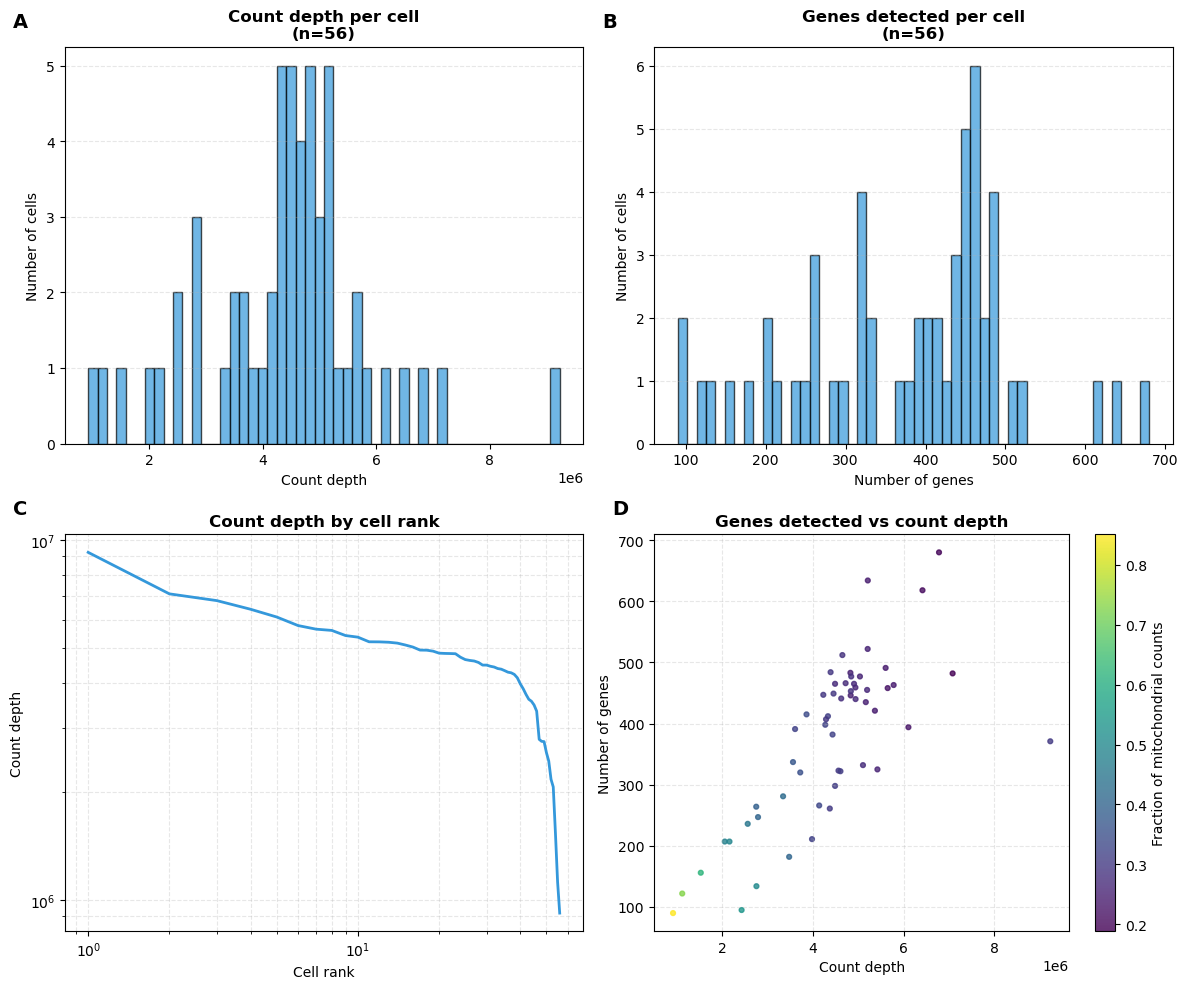

In [6]:
plot_qc_overview(raw_data)

Re-run with candidate thresholds, e.g. `plot_qc_overview(raw_data, count_threshold=..., gene_threshold=...)`.

## Mitochondrial, rRNA and apoptosis fractions

Each panel plots the fraction of counts from one gene set against count depth, with the threshold from `config.yaml`. Red cells are above the threshold and are removed by that filter.
If the red cells are also the low-count ones, they are likely damaged; high fractions across all count depths may be biology.

**Note:** only 2,874 of the 48,440 genes in this matrix have any counts, and none of the apoptosis genes are among them, so every apoptosis fraction is 0.

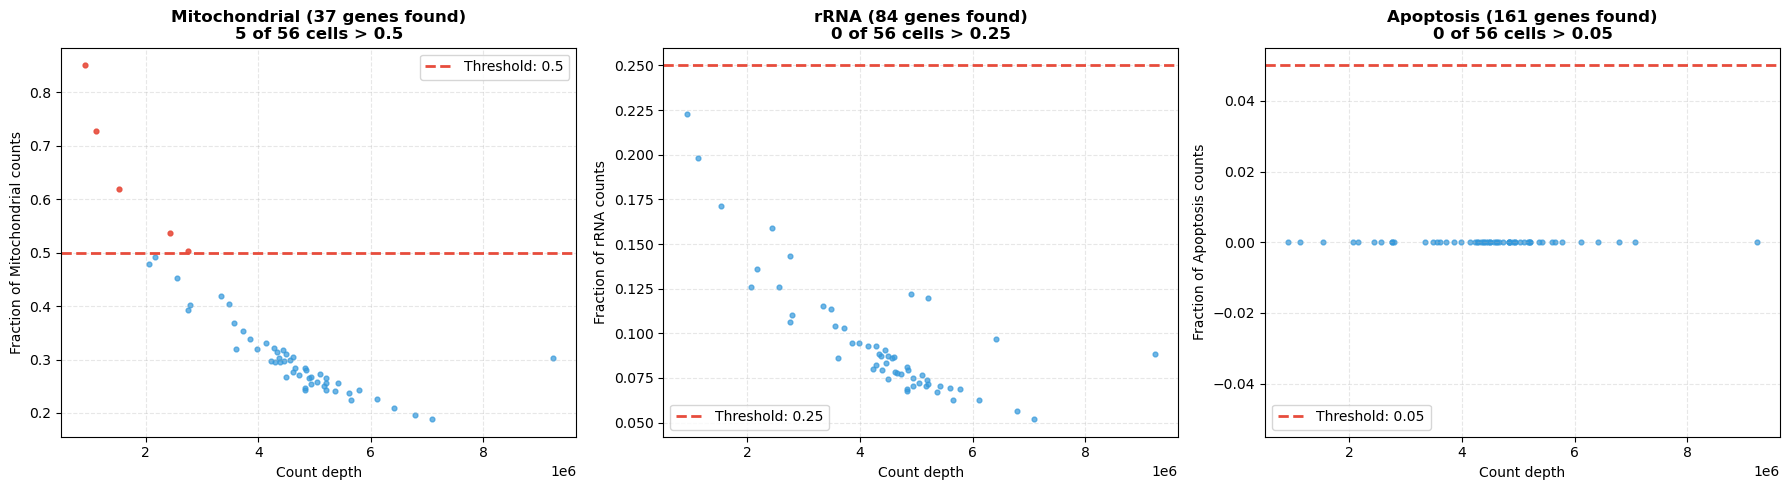

In [7]:
plot_gene_set_qc(raw_data, SPECIES, preprocessing_config)

## Apply filters

Runs the same filtering as the benchmark pipeline (cell QC on the raw matrix, then the gene filter), using the thresholds from `config.yaml`.

In [8]:
clean_data = run_filtering_pipeline(raw_data, config=preprocessing_config, species=SPECIES)

clean_data.shape

(51, 2862)

# Gene Filtering

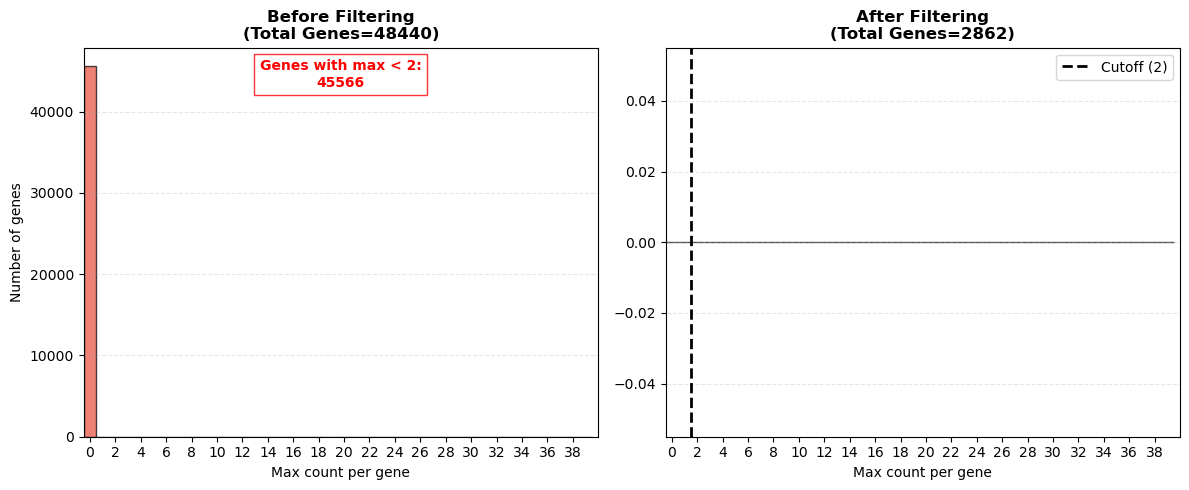

In [9]:
plot_gene_max_count_distribution(raw_data, clean_data, x_limit=40)

## Doublets

If we run scrublet we get this error: "ValueError: n_components=30 must be between 1 and min(n_samples, n_features)=9 with svd_solver='arpack'". 56 cells are not enough for calculating doublets. 

# Normalization

## logCPM

### Normalize by library size

In [10]:
normalized_data = normalize_by_library_size(clean_data)

normalized_data.shape

(51, 2862)

### Log Transform

In [11]:
logged_data = log_transform(normalized_data)

logged_data.shape

(51, 2862)

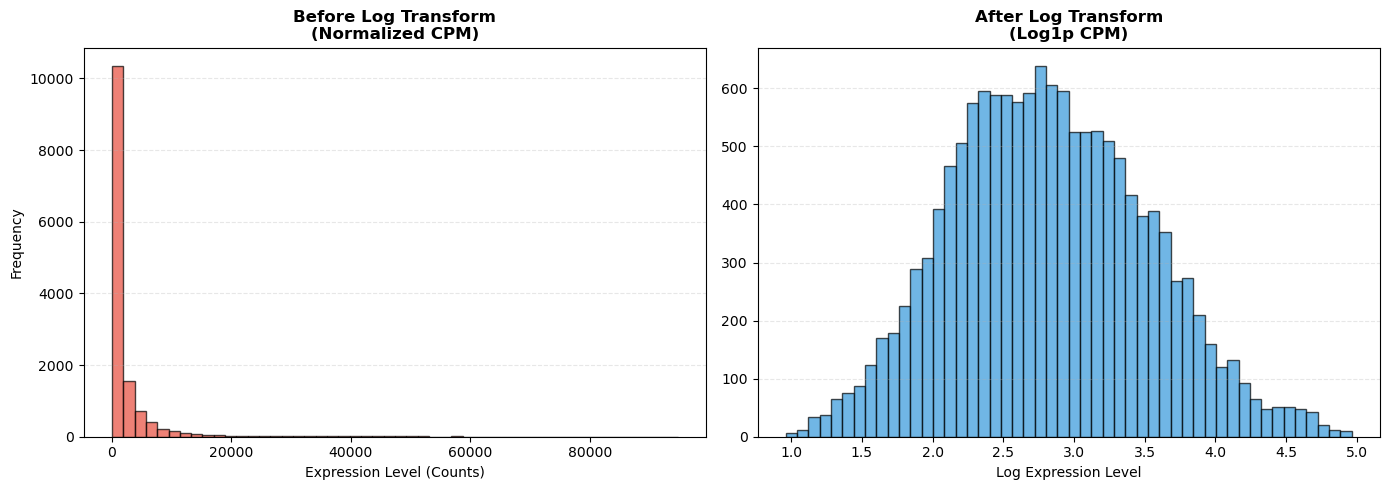

In [14]:
plot_log_transform_comparison(normalized_data, logged_data)

## Pearson residuals

In [12]:
pearsons_data = normalize_with_pearson(clean_data)

pearsons_data.shape

/opt/anaconda3/envs/scrna-seq-clustering/lib/python3.14/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(51, 2862)

In [13]:
pearsons_data.head()

,Gm2053,Gm6104,Gm37277,Gm2147,Gm15452,Gm22607,Snord87,1700047N06Rik,Gm26348,Gm5250,...,mt-Tr,mt-Th,mt-Ts2,mt-Tl2,mt-Nd5,mt-Nd6,mt-Te,mt-Cytb,mt-Tt,mt-Tp
GSM1377886,-6.734179,-7.141428,-7.141428,-7.141428,-7.141428,-2.773205,-7.141428,-7.141428,-6.733608,-7.141428,...,-0.151431,2.832971,0.505634,1.499850,-1.766072,-1.385230,-0.324528,-2.650823,0.711304,-1.288774
GSM1377866,-4.766007,-6.649782,-6.302454,-7.141428,-7.141428,-1.693029,-7.141428,-5.202242,-4.765436,7.141428,...,-0.207139,1.688880,0.162272,1.533143,5.945329,3.455292,0.504205,7.141428,7.141428,5.305259
GSM1377897,-6.061412,-7.141428,-7.141428,-7.141428,-7.141428,-2.347348,2.770508,-6.504195,-6.060818,-7.141428,...,2.416217,1.767273,2.620887,1.578211,1.555355,1.224758,0.043815,0.787726,4.067016,3.164839
GSM1377898,-6.187675,-7.141428,-7.141428,-7.141428,-7.141428,-2.421539,7.141428,-6.627423,-6.187083,-7.141428,...,2.601492,2.189532,3.248766,0.457172,0.383036,1.017568,1.979839,0.065493,2.215269,2.584693
GSM1377870,-6.925028,-7.141428,-7.141428,-7.141428,-7.141428,-2.910016,-5.197879,-7.141428,-6.924470,7.141428,...,-0.533350,-1.340932,-2.245900,-2.495604,-3.182079,-3.564959,-3.324891,-3.078803,-2.874843,-3.525557
